✓ Data loaded: (1111, 18)

=== TARGET VARIABLE ===
is_satisfied
0    667
1    444
Name: count, dtype: int64

✓ Features prepared: (1111, 11)

✓ Train size : 888
✓ Test size  : 223

Training Logistic Regression...
✓ Logistic Regression trained!

Training Random Forest...
✓ Random Forest trained!

LOGISTIC REGRESSION RESULTS
               precision    recall  f1-score   support

Not Satisfied       0.85      0.90      0.87       134
    Satisfied       0.84      0.75      0.79        89

     accuracy                           0.84       223
    macro avg       0.84      0.83      0.83       223
 weighted avg       0.84      0.84      0.84       223

RANDOM FOREST RESULTS
               precision    recall  f1-score   support

Not Satisfied       0.86      0.90      0.88       134
    Satisfied       0.83      0.79      0.81        89

     accuracy                           0.85       223
    macro avg       0.85      0.84      0.84       223
 weighted avg       0.85      0.85      0.8

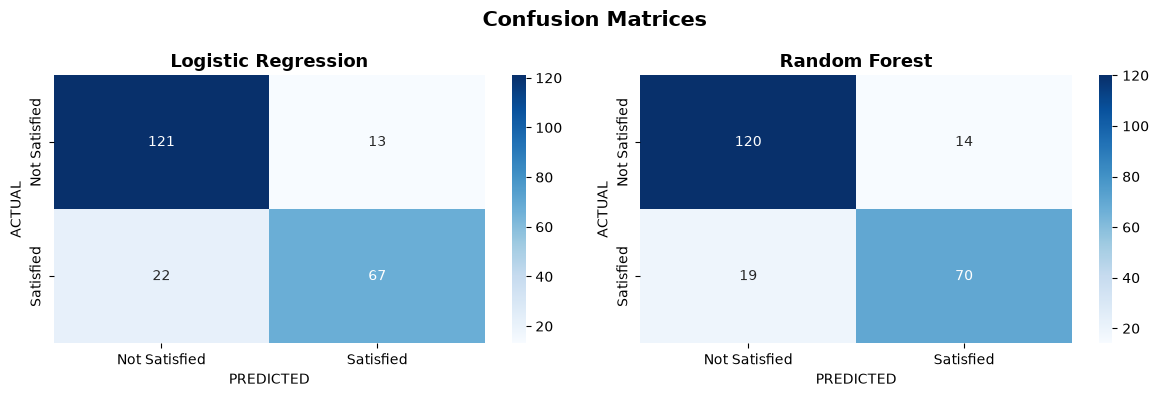

✓ Confusion matrix chart saved!


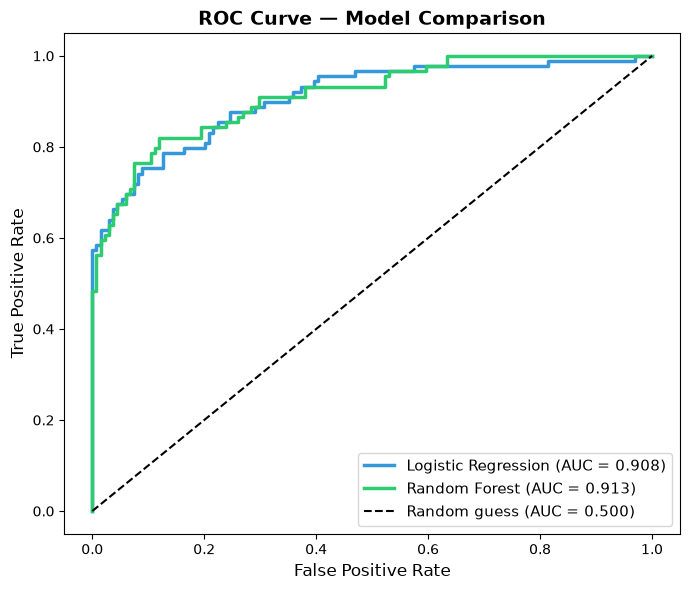

✓ ROC curve chart saved!


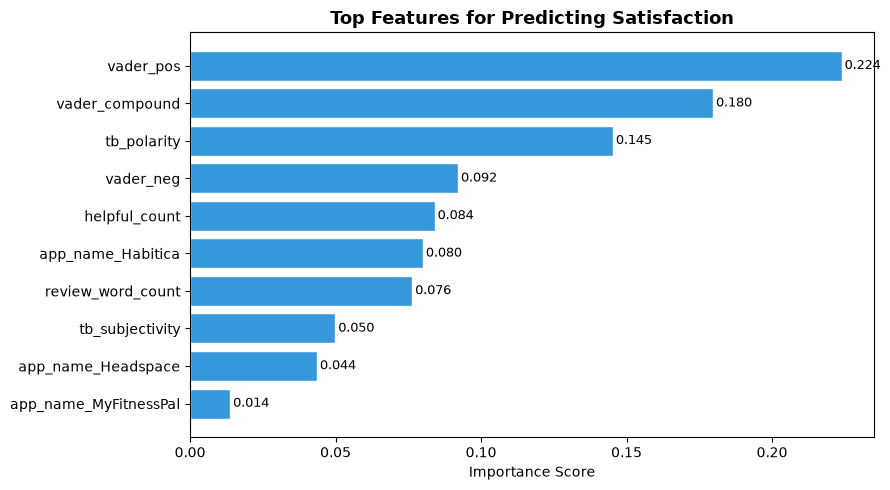

✓ Feature importance chart saved!

   COMPLETE PROJECT SUMMARY

📊 DATASET
   Total reviews    : 1111
   Apps covered     : 4
   Average rating   : 2.79 stars

🤖 MODEL PERFORMANCE
   Logistic Regression → Accuracy: 84.3%  AUC: 0.908
   Random Forest       → Accuracy: 85.2%  AUC: 0.913

🏆 TOP 5 IMPORTANT FEATURES
   vader_pos                 0.2239
   vader_compound            0.1797
   tb_polarity               0.1453
   vader_neg                 0.0921
   helpful_count             0.0841

✓ All done! Project Complete!


In [1]:
# COMPLETE ML MODEL — All in one cell
# This avoids any variable scope issues

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve,
                             accuracy_score)
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# =============================================
# STEP 1: LOAD DATA
# =============================================
df = pd.read_csv('data/sentiment_reviews.csv')
print("✓ Data loaded:", df.shape)

# =============================================
# STEP 2: CREATE TARGET VARIABLE
# =============================================
df['is_satisfied'] = (df['rating'] >= 4).astype(int)

print("\n=== TARGET VARIABLE ===")
print(df['is_satisfied'].value_counts())

# =============================================
# STEP 3: PREPARE FEATURES
# =============================================
features = [
    'vader_compound',
    'vader_pos',
    'vader_neg',
    'tb_polarity',
    'tb_subjectivity',
    'review_word_count',
    'helpful_count',
]

df_model = pd.get_dummies(
    df[features + ['app_name', 'is_satisfied']],
    columns=['app_name']
)

feature_cols = [c for c in df_model.columns if c != 'is_satisfied']
X = df_model[feature_cols]
y = df_model['is_satisfied']

print("\n✓ Features prepared:", X.shape)

# =============================================
# STEP 4: SPLIT DATA
# =============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✓ Train size : {len(X_train)}")
print(f"✓ Test size  : {len(X_test)}")

# =============================================
# STEP 5: TRAIN LOGISTIC REGRESSION
# =============================================
print("\nTraining Logistic Regression...")
lr_model  = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("✓ Logistic Regression trained!")

# =============================================
# STEP 6: TRAIN RANDOM FOREST
# =============================================
print("\nTraining Random Forest...")
rf_model  = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("✓ Random Forest trained!")

# =============================================
# STEP 7: PRINT RESULTS
# =============================================
print("\n" + "="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Not Satisfied', 'Satisfied']
))

print("="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Not Satisfied', 'Satisfied']
))

lr_auc = roc_auc_score(y_test, y_prob_lr)
rf_auc = roc_auc_score(y_test, y_prob_rf)
lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"Logistic Regression → Accuracy: {lr_acc:.1%}  AUC: {lr_auc:.3f}")
print(f"Random Forest       → Accuracy: {rf_acc:.1%}  AUC: {rf_auc:.3f}")

# =============================================
# STEP 8: CONFUSION MATRIX CHART
# =============================================
os.makedirs('outputs/charts', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (y_pred, model_name) in zip(axes, [
    (y_pred_lr, 'Logistic Regression'),
    (y_pred_rf, 'Random Forest')
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Not Satisfied', 'Satisfied'],
        yticklabels=['Not Satisfied', 'Satisfied']
    )
    ax.set_title(f'{model_name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('ACTUAL')
    ax.set_xlabel('PREDICTED')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/charts/09_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Confusion matrix chart saved!")

# =============================================
# STEP 9: ROC CURVE CHART
# =============================================
fig, ax = plt.subplots(figsize=(7, 6))

for y_prob, model_name, color in [
    (y_prob_lr, 'Logistic Regression', '#3498db'),
    (y_prob_rf, 'Random Forest',       '#2ecc71')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr,
            label=f'{model_name} (AUC = {auc:.3f})',
            color=color,
            linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--',
        label='Random guess (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Model Comparison',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('outputs/charts/10_roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ ROC curve chart saved!")

# =============================================
# STEP 10: FEATURE IMPORTANCE CHART
# =============================================
importance_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    importance_df['feature'][::-1],
    importance_df['importance'][::-1],
    color='#3498db',
    edgecolor='white'
)

for bar, val in zip(bars, importance_df['importance'][::-1]):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}',
        va='center',
        fontsize=9
    )

ax.set_title('Top Features for Predicting Satisfaction',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/charts/11_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Feature importance chart saved!")

# =============================================
# STEP 11: FINAL SUMMARY
# =============================================
print("\n" + "="*50)
print("   COMPLETE PROJECT SUMMARY")
print("="*50)

print(f"\n📊 DATASET")
print(f"   Total reviews    : {len(df)}")
print(f"   Apps covered     : {df['app_name'].nunique()}")
print(f"   Average rating   : {df['rating'].mean():.2f} stars")

print(f"\n🤖 MODEL PERFORMANCE")
print(f"   Logistic Regression → Accuracy: {lr_acc:.1%}  AUC: {lr_auc:.3f}")
print(f"   Random Forest       → Accuracy: {rf_acc:.1%}  AUC: {rf_auc:.3f}")

print(f"\n🏆 TOP 5 IMPORTANT FEATURES")
for _, row in importance_df.head(5).iterrows():
    print(f"   {row['feature']:25} {row['importance']:.4f}")

print("\n" + "="*50)
print("✓ All done! Project Complete!")
print("="*50)